# Data Provenance — read before the EDA

This EDA currently loads the **CSV snapshot** (`processed/final-reviews-*.csv`),
which predates two cleaning steps and therefore reports inflated counts. The full
provenance is documented in [`data-management/DATA_PROVENANCE.md`](../data-management/DATA_PROVENANCE.md).

**Pipeline funnel:**

```
8,574 catalogue hotels
  → 1,150  (number_of_reviews > 500, hotel_filtered.csv)
  → 503    (manually selected for Google-Maps scrape)
  → preprocess: drop empty/rating-only · drop <5-word · drop duplicates
  → re-apply 1,150 filter (removes the Agoda "leak")
  → 610 hotels · 174,371 reviews   ← FINAL analysis corpus (canonical db)
```

**Two snapshots — mind which one you read:**

| Source | Reviews | Hotels | State |
|---|---|---|---|
| `data/hotel_reviews.db` (**canonical**) | 174,371 | 610 | short reviews removed, leak fixed, has labels |
| `processed/final-reviews-*.csv` (loaded below) | 196,630 | 614 | short reviews present, pre-leak-fix |

**Final corpus (canonical):** 610 hotels · 174,371 en/vi reviews —
Agoda 62,129 / Google 112,242; 121 hotels on both platforms; en 89,163 / vi 85,208.
174 hotels (28.5%) lie within 1 km of the coast.

> **Caveats for the write-up.** (a) The 1,150 filter used Agoda's *claimed* review
> count, so 536 of those hotels have no captured en/vi reviews and are absent from
> the corpus. (b) Platform coverage is mostly single-platform — only 121 hotels
> appear on both. (c) Earlier "1,704 hotels / 252k reviews / balanced platforms"
> figures came from a pre-cleaning snapshot and should not be cited.

*The cells below still read the CSV snapshot. To match the canonical figures, filter
to the 1,150 hotel set (and prefer the db) — see the provenance doc.*


# 23 — Exploratory Data Analysis of the Hotel Review Corpus

**Goal.** Provide a complete, reproducible exploratory data analysis (EDA) of the
integrated Agoda + Google Maps review corpus used in this study, following a
standard data-analysis procedure:

1. Data loading & integration
2. Basic information (structure, types, sample)
3. Data-quality assessment (missingness, duplicates, validity)
4. Univariate analysis — review level
5. Univariate analysis — hotel level
6. Bivariate / multivariate relationships
7. Temporal analysis
8. Coastal-proximity analysis (the study's focal gradient)
9. Platform-coverage analysis
10. Key findings

**Units of analysis.** *Review* (guest experience) and *Hotel* (supply side).
Each review is linked to its hotel record, inheriting `star_rating`,
`accommodation_type`, `numberrooms`, and the derived `distance2coastline`.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
PALETTE = ["#2c7fb8", "#e6550d", "#31a354", "#756bb1", "#636363"]
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

## 1. Data loading & integration

In [2]:
# Resolve the data directory (the active, rating-fixed copy).
CANDIDATES = [
    "../data-management/data",
    "../data",
    "data-management/data",
    "data",
]
DATA_DIR = next((p for p in CANDIDATES
                 if os.path.exists(os.path.join(p, "processed", "final-reviews-en.csv"))), None)
assert DATA_DIR is not None, "Could not locate processed/final-reviews-en.csv"
PROC = os.path.join(DATA_DIR, "processed")
print("Using DATA_DIR =", os.path.abspath(DATA_DIR))

Using DATA_DIR = C:\Users\darkn\coastal-hotel\data-management\data


In [3]:
# Review corpus (English + Vietnamese), already language-filtered & preprocessed.
rev_cols = ["review_text", "language", "rating", "review_year", "review_month",
            "review_period", "stay_nights", "hotel_id", "hotel_name", "source"]
en = pd.read_csv(os.path.join(PROC, "final-reviews-en.csv"), usecols=rev_cols)
vi = pd.read_csv(os.path.join(PROC, "final-reviews-vi.csv"), usecols=rev_cols)
reviews = pd.concat([en, vi], ignore_index=True)
print(f"English reviews:    {len(en):,}")
print(f"Vietnamese reviews: {len(vi):,}")
print(f"Combined reviews:   {len(reviews):,}")

English reviews:    135,326
Vietnamese reviews: 117,522
Combined reviews:   252,848


In [4]:
# Hotel (supply-side) attributes, including coastal distance.
hot_cols = ["hotel_id", "hotel_name", "city", "state", "star_rating",
            "numberrooms", "yearopened", "distance2coastline", "accommodation_type"]
hotels = (pd.read_csv(os.path.join(DATA_DIR, "hotel_with_distance.csv"), usecols=hot_cols)
            .drop_duplicates("hotel_id"))
# Clean obvious sentinels
hotels.loc[hotels["yearopened"] < 1900, "yearopened"] = np.nan
hotels.loc[hotels["star_rating"] == 0, "star_rating"] = np.nan
hotels.loc[hotels["numberrooms"] == 0, "numberrooms"] = np.nan
print(f"Hotels in catalogue: {len(hotels):,}")

# Integrated review-level frame with hotel attributes.
df = reviews.merge(
    hotels[["hotel_id", "city", "state", "star_rating", "numberrooms",
            "yearopened", "distance2coastline", "accommodation_type"]],
    on="hotel_id", how="left")
df["review_length"] = df["review_text"].fillna("").str.split().apply(len)
print(f"Integrated frame: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Unique hotels in corpus: {df['hotel_id'].nunique():,}")

Hotels in catalogue: 8,574


Integrated frame: 252,848 rows x 18 cols
Unique hotels in corpus: 1,704


## 2. Basic information

In [5]:
import io
buf = io.StringIO()
df.info(buf=buf)
print(buf.getvalue())

<class 'pandas.DataFrame'>
RangeIndex: 252848 entries, 0 to 252847
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   review_text         252848 non-null  str    
 1   language            252848 non-null  str    
 2   rating              247780 non-null  float64
 3   review_year         252815 non-null  float64
 4   review_month        252815 non-null  float64
 5   review_period       252815 non-null  str    
 6   stay_nights         125347 non-null  float64
 7   hotel_id            252848 non-null  int64  
 8   hotel_name          252848 non-null  str    
 9   source              252848 non-null  str    
 10  city                252848 non-null  str    
 11  state               238175 non-null  str    
 12  star_rating         247430 non-null  float64
 13  numberrooms         250629 non-null  float64
 14  yearopened          202005 non-null  float64
 15  distance2coastline  252848 non-null  float64


In [6]:
# Sample of the integrated frame
df.head(5)

,review_text,language,rating,review_year,review_month,review_period,stay_nights,hotel_id,hotel_name,source,city,state,star_rating,numberrooms,yearopened,distance2coastline,accommodation_type,review_length
0,A tourist class hotel with very basic amenitie...,en,3.20,2024.0,1.0,2024-01,4.0,163,Ramana Saigon Hotel,agoda,Ho Chi Minh City,NaN,4.0,296.0,1996.0,47.465,Hotel,28
1,The hotel rooms etc are good but very very sti...,en,3.80,2024.0,1.0,2024-01,2.0,163,Ramana Saigon Hotel,agoda,Ho Chi Minh City,NaN,4.0,296.0,1996.0,47.465,Hotel,37
2,Really enjoy my stay here. Will stay again,en,4.35,2015.0,4.0,2015-04,4.0,163,Ramana Saigon Hotel,agoda,Ho Chi Minh City,NaN,4.0,296.0,1996.0,47.465,Hotel,8
3,excellent,en,4.60,2024.0,2.0,2024-02,2.0,163,Ramana Saigon Hotel,agoda,Ho Chi Minh City,NaN,4.0,296.0,1996.0,47.465,Hotel,1
4,Great and decent place for sightseeing and tours,en,4.00,2024.0,2.0,2024-02,3.0,163,Ramana Saigon Hotel,agoda,Ho Chi Minh City,NaN,4.0,296.0,1996.0,47.465,Hotel,8


In [7]:
# Numeric summary
df[["rating", "review_length", "review_year", "stay_nights",
    "star_rating", "numberrooms", "distance2coastline"]].describe().round(2)

,rating,review_length,review_year,stay_nights,star_rating,numberrooms,distance2coastline
count,247780.00,252848.00,252815.00,125347.00,247430.00,250629.00,252848.00
mean,4.21,36.98,2021.40,2.05,3.47,93.05,48.41
std,1.09,43.55,3.97,1.57,0.98,101.63,63.31
min,1.00,1.00,2004.00,1.00,1.00,1.00,0.00
25%,4.00,11.00,2019.00,1.00,3.00,30.00,0.47
50%,4.80,26.00,2023.00,2.00,3.50,56.00,44.64
75%,5.00,49.00,2025.00,3.00,4.00,111.00,73.17
max,5.00,1365.00,2026.00,41.00,5.00,1000.00,401.41


In [8]:
# Categorical summary
df[["language", "source", "review_period", "accommodation_type", "city"]].describe(include="object")

C:\Users\darkn\AppData\Local\Temp\ipykernel_20588\1089481044.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df[["language", "source", "review_period", "accommodation_type", "city"]].describe(include="object")


,language,source,review_period,accommodation_type,city
count,252848,252848,252815,252848,252848
unique,2,2,216,9,85
top,en,googlemaps,2025-03,Hotel,Ho Chi Minh City
freq,135326,127501,22131,237934,67250


## 3. Data-quality assessment

,missing,missing_%
stay_nights,127501,50.43
yearopened,50843,20.11
state,14673,5.80
star_rating,5418,2.14
rating,5068,2.00
numberrooms,2219,0.88
review_period,33,0.01
review_year,33,0.01
review_month,33,0.01


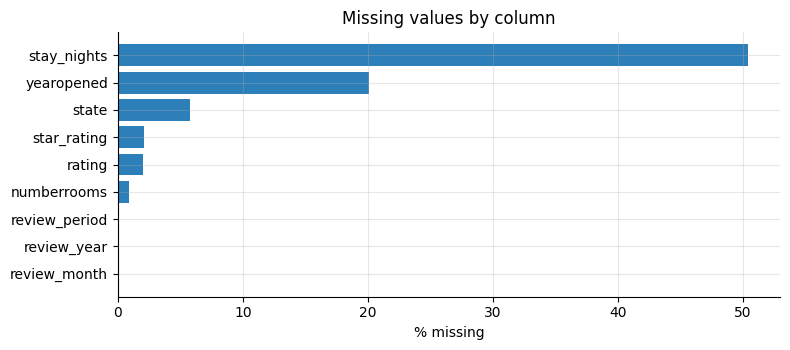

In [9]:
# 3a. Missingness per column
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
quality = pd.DataFrame({"missing": miss, "missing_%": miss_pct})
display(quality)

fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(quality))))
ax.barh(quality.index[::-1], quality["missing_%"][::-1], color=PALETTE[0])
ax.set_xlabel("% missing"); ax.set_title("Missing values by column")
plt.tight_layout(); plt.show()

In [10]:
# 3b. Duplicates and rating validity (post-fix sanity check)
exact_dups = df.duplicated().sum()
text_dups = df.duplicated(subset=["hotel_id", "review_text", "source"]).sum()
r = pd.to_numeric(df["rating"], errors="coerce")
print(f"Exact duplicate rows:                 {exact_dups:,}")
print(f"Duplicate (hotel_id, text, source):   {text_dups:,}")
print(f"rating range: [{r.min()}, {r.max()}]  | out-of-[1,5]: {((r < 1) | (r > 5)).sum()}")
print(f"rating missing: {r.isna().sum():,} ({r.isna().mean()*100:.2f}%)")
print("=> rating is clean on the 1-5 scale." if ((r.dropna() >= 1) & (r.dropna() <= 5)).all()
      else "=> WARNING: invalid ratings remain.")

Exact duplicate rows:                 1,328
Duplicate (hotel_id, text, source):   4,076
rating range: [1.0, 5.0]  | out-of-[1,5]: 0
rating missing: 5,068 (2.00%)
=> rating is clean on the 1-5 scale.


## 4. Univariate analysis — review level

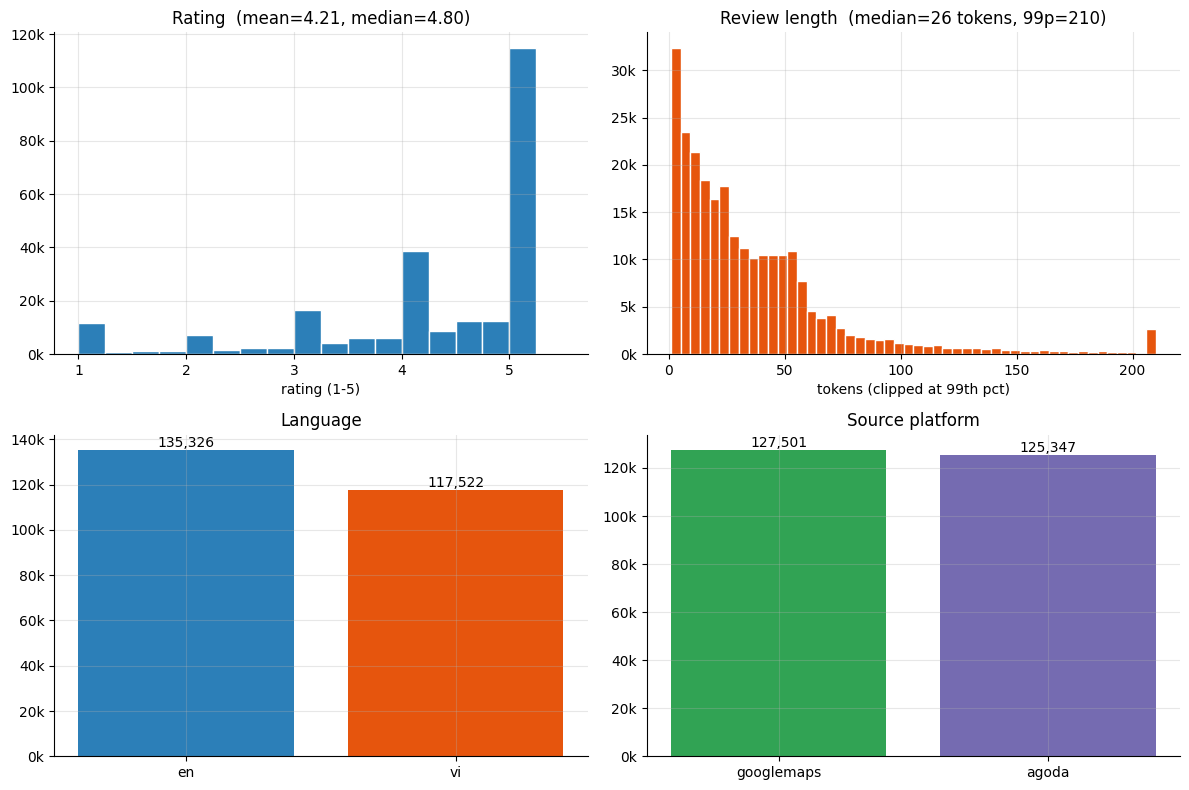

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Rating
r = pd.to_numeric(df["rating"], errors="coerce").dropna()
axes[0, 0].hist(r, bins=np.arange(1, 5.6, 0.25), color=PALETTE[0], edgecolor="white")
axes[0, 0].set_title(f"Rating  (mean={r.mean():.2f}, median={r.median():.2f})")
axes[0, 0].set_xlabel("rating (1-5)")

# Review length (clipped at 99th pct for readability)
L = df["review_length"]
cap = int(L.quantile(0.99))
axes[0, 1].hist(L.clip(upper=cap), bins=50, color=PALETTE[1], edgecolor="white")
axes[0, 1].set_title(f"Review length  (median={L.median():.0f} tokens, 99p={cap})")
axes[0, 1].set_xlabel("tokens (clipped at 99th pct)")

# Language
lc = df["language"].value_counts()
axes[1, 0].bar(lc.index, lc.values, color=PALETTE[:len(lc)])
axes[1, 0].set_title("Language")
for i, v in enumerate(lc.values):
    axes[1, 0].text(i, v, f"{v:,}", ha="center", va="bottom")

# Source
sc = df["source"].value_counts()
axes[1, 1].bar(sc.index, sc.values, color=PALETTE[2:4])
axes[1, 1].set_title("Source platform")
for i, v in enumerate(sc.values):
    axes[1, 1].text(i, v, f"{v:,}", ha="center", va="bottom")

for ax in axes.ravel():
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
plt.tight_layout(); plt.show()

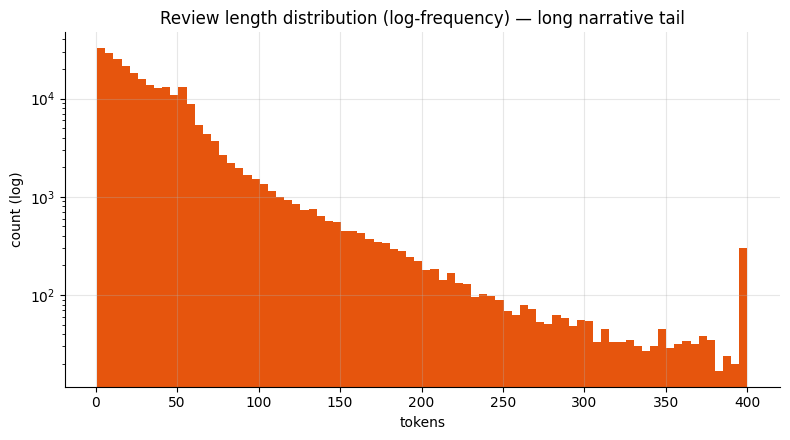

count    252848.0
mean         37.0
std          43.5
min           1.0
50%          26.0
90%          75.0
95%         109.0
99%         210.0
max        1365.0
Name: review_length, dtype: float64


In [12]:
# Right-skew of review length on a log y-axis
fig, ax = plt.subplots()
ax.hist(df["review_length"].clip(upper=400), bins=80, color=PALETTE[1])
ax.set_yscale("log")
ax.set_title("Review length distribution (log-frequency) — long narrative tail")
ax.set_xlabel("tokens"); ax.set_ylabel("count (log)")
plt.tight_layout(); plt.show()
print(df["review_length"].describe(percentiles=[.5, .9, .95, .99]).round(1))

## 5. Univariate analysis — hotel level

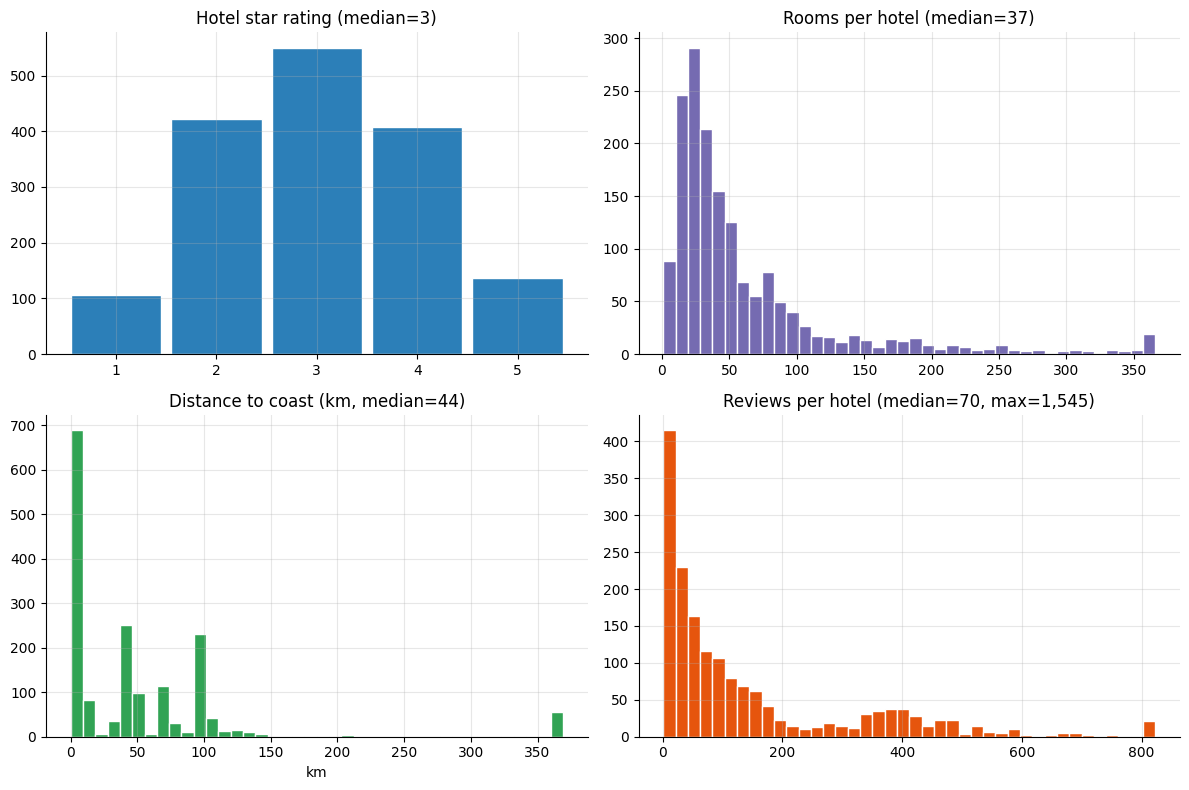

In [13]:
H = hotels[hotels["hotel_id"].isin(df["hotel_id"].unique())].copy()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sr = H["star_rating"].dropna()
axes[0, 0].hist(sr, bins=np.arange(0.5, 6, 1), color=PALETTE[0], edgecolor="white", rwidth=0.9)
axes[0, 0].set_title(f"Hotel star rating (median={sr.median():.0f})")

nr = H["numberrooms"].dropna()
axes[0, 1].hist(nr.clip(upper=int(nr.quantile(0.99))), bins=40, color=PALETTE[3], edgecolor="white")
axes[0, 1].set_title(f"Rooms per hotel (median={nr.median():.0f})")

dc = H["distance2coastline"].dropna()
axes[1, 0].hist(dc.clip(upper=int(dc.quantile(0.99))), bins=40, color=PALETTE[2], edgecolor="white")
axes[1, 0].set_title(f"Distance to coast (km, median={dc.median():.0f})")
axes[1, 0].set_xlabel("km")

rph = df.groupby("hotel_id").size()
axes[1, 1].hist(rph.clip(upper=int(rph.quantile(0.99))), bins=40, color=PALETTE[1], edgecolor="white")
axes[1, 1].set_title(f"Reviews per hotel (median={rph.median():.0f}, max={rph.max():,})")
plt.tight_layout(); plt.show()

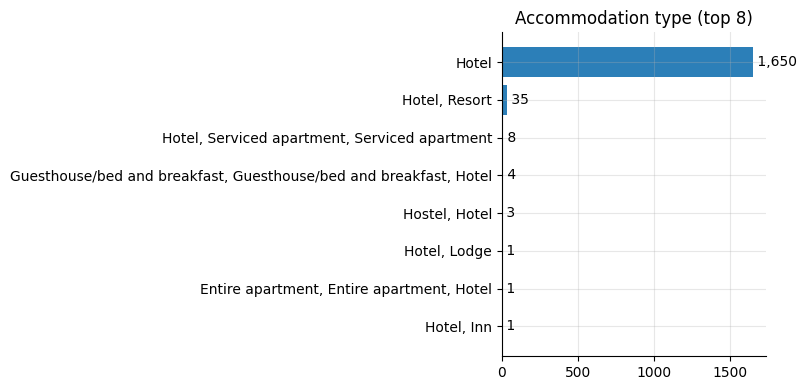

In [14]:
# Accommodation-type composition (top categories)
ac = H["accommodation_type"].value_counts().head(8)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(ac.index[::-1], ac.values[::-1], color=PALETTE[0])
ax.set_title("Accommodation type (top 8)")
for i, v in enumerate(ac.values[::-1]):
    ax.text(v, i, f" {v:,}", va="center")
plt.tight_layout(); plt.show()

## 6. Bivariate / multivariate relationships

C:\Users\darkn\AppData\Local\Temp\ipykernel_20588\154431659.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
C:\Users\darkn\AppData\Local\Temp\ipykernel_20588\154431659.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)


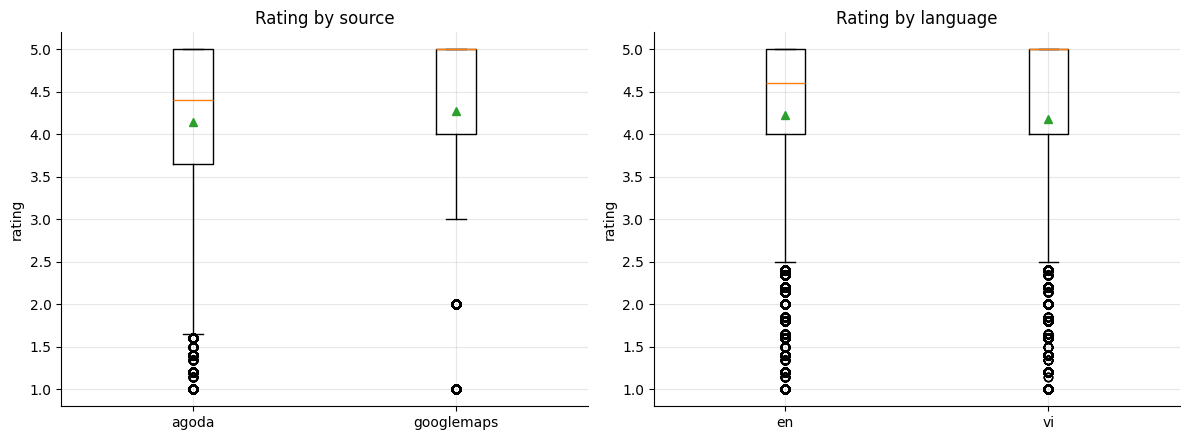

             count  mean  median   std
source                                
agoda       125344  4.15     4.4  0.96
googlemaps  122436  4.27     5.0  1.21

           count  mean  median   std
language                            
en        132692  4.23     4.6  1.01
vi        115088  4.18     5.0  1.18


In [15]:
# 6a. Rating by source and by language (boxplots)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, key, title in [(axes[0], "source", "Rating by source"),
                       (axes[1], "language", "Rating by language")]:
    groups = [pd.to_numeric(df.loc[df[key] == k, "rating"], errors="coerce").dropna()
              for k in df[key].dropna().unique()]
    labels = list(df[key].dropna().unique())
    ax.boxplot(groups, labels=labels, showmeans=True)
    ax.set_title(title); ax.set_ylabel("rating")
plt.tight_layout(); plt.show()

print(df.groupby("source")["rating"].agg(["count", "mean", "median", "std"]).round(2))
print()
print(df.groupby("language")["rating"].agg(["count", "mean", "median", "std"]).round(2))

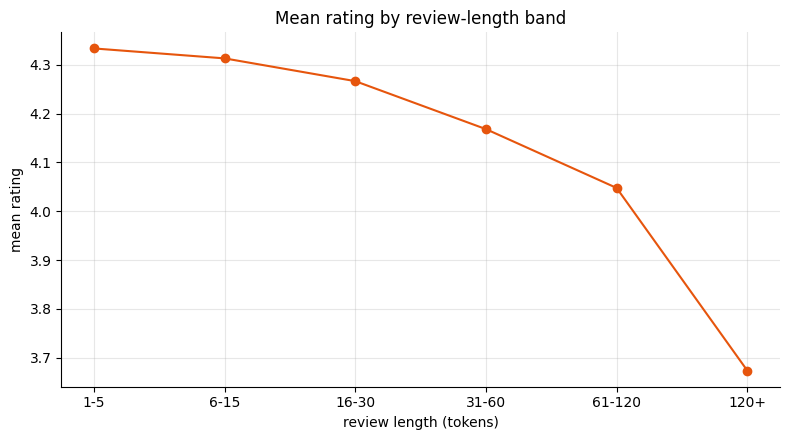

Pearson corr(rating, review_length) = -0.136


In [16]:
# 6b. Rating vs review length (does sentiment relate to verbosity?)
tmp = df[["rating", "review_length"]].dropna()
bins = [0, 5, 15, 30, 60, 120, np.inf]
labels = ["1-5", "6-15", "16-30", "31-60", "61-120", "120+"]
tmp["len_bin"] = pd.cut(tmp["review_length"], bins=bins, labels=labels)
g = tmp.groupby("len_bin", observed=True)["rating"].mean()
fig, ax = plt.subplots()
ax.plot(g.index.astype(str), g.values, marker="o", color=PALETTE[1])
ax.set_title("Mean rating by review-length band")
ax.set_xlabel("review length (tokens)"); ax.set_ylabel("mean rating")
plt.tight_layout(); plt.show()
print("Pearson corr(rating, review_length) =",
      round(tmp["rating"].corr(tmp["review_length"]), 3))

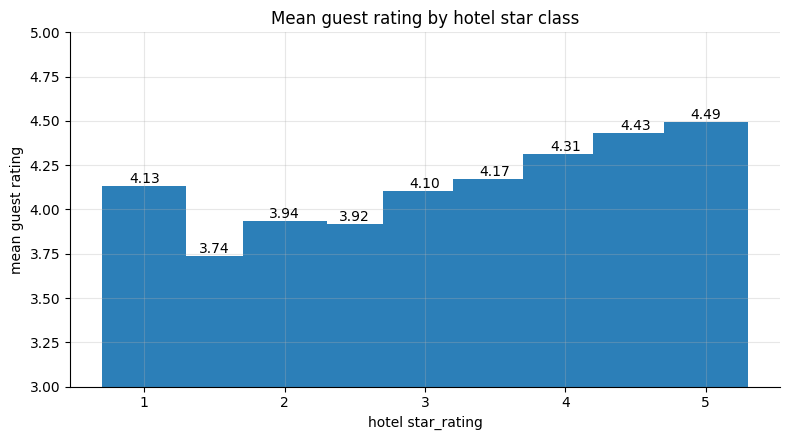

             mean  count
star_rating             
1.0          4.13   6191
1.5          3.74   2665
2.0          3.94  26655
2.5          3.92   9373
3.0          4.10  65452
3.5          4.17  16137
4.0          4.31  76400
4.5          4.43   8349
5.0          4.49  31160


In [17]:
# 6c. Guest rating vs hotel star rating
tmp = df.dropna(subset=["rating", "star_rating"])
g = tmp.groupby("star_rating")["rating"].agg(["mean", "count"])
fig, ax = plt.subplots()
ax.bar(g.index, g["mean"], color=PALETTE[0], width=0.6)
ax.set_ylim(3, 5); ax.set_title("Mean guest rating by hotel star class")
ax.set_xlabel("hotel star_rating"); ax.set_ylabel("mean guest rating")
for x, m in zip(g.index, g["mean"]):
    ax.text(x, m, f"{m:.2f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()
print(g.round(2))

## 7. Temporal analysis

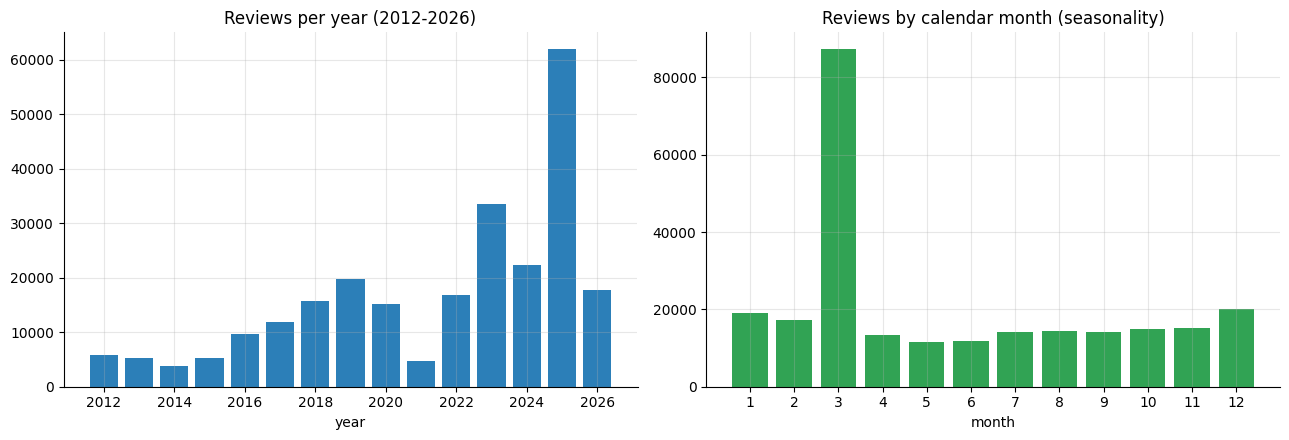

In [18]:
# Reviews per year and intra-year seasonality
yr = df["review_year"].dropna()
yr = yr[(yr >= 2012) & (yr <= 2026)]
by_year = yr.value_counts().sort_index()
mo = df["review_month"].dropna()
by_month = mo[(mo >= 1) & (mo <= 12)].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(by_year.index, by_year.values, color=PALETTE[0])
axes[0].set_title("Reviews per year (2012-2026)"); axes[0].set_xlabel("year")
axes[1].bar(by_month.index, by_month.values, color=PALETTE[2])
axes[1].set_title("Reviews by calendar month (seasonality)")
axes[1].set_xlabel("month"); axes[1].set_xticks(range(1, 13))
plt.tight_layout(); plt.show()

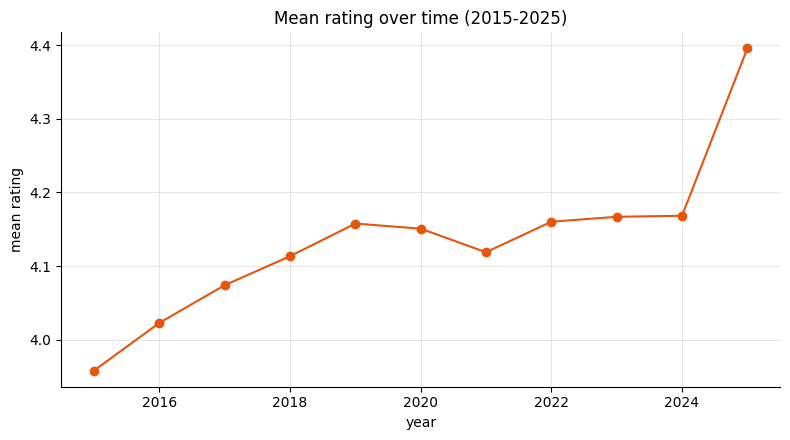

review_year
2015.0    3.958
2016.0    4.023
2017.0    4.074
2018.0    4.113
2019.0    4.158
2020.0    4.151
2021.0    4.119
2022.0    4.160
2023.0    4.167
2024.0    4.168
2025.0    4.396
Name: rating, dtype: float64


In [19]:
# Rating trend over time
tmp = df.dropna(subset=["rating", "review_year"])
tmp = tmp[(tmp["review_year"] >= 2015) & (tmp["review_year"] <= 2025)]
g = tmp.groupby("review_year")["rating"].mean()
fig, ax = plt.subplots()
ax.plot(g.index, g.values, marker="o", color=PALETTE[1])
ax.set_title("Mean rating over time (2015-2025)")
ax.set_xlabel("year"); ax.set_ylabel("mean rating")
plt.tight_layout(); plt.show()
print(g.round(3))

## 8. Coastal-proximity analysis

The study's focal variable is `distance2coastline`. We bin hotels into proximity
bands and test whether guest satisfaction varies along the coastal gradient.

,reviews,hotels,mean_rating,median_rating
coast_band,,,,
<1 km,72403,571,4.173,4.65
1-5 km,16245,102,4.420,5.00
5-20 km,15170,97,4.399,5.00
20-50 km,66118,352,4.080,4.60
50+ km,77844,579,4.268,4.80


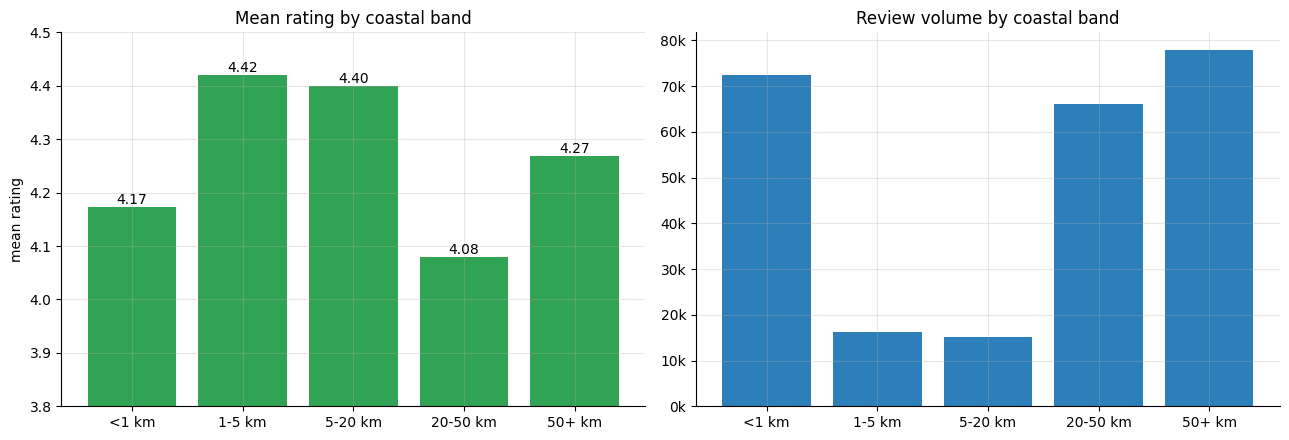

Pearson corr(rating, distance2coastline) = 0.025


In [20]:
tmp = df.dropna(subset=["rating", "distance2coastline"]).copy()
bins = [0, 1, 5, 20, 50, np.inf]
labels = ["<1 km", "1-5 km", "5-20 km", "20-50 km", "50+ km"]
tmp["coast_band"] = pd.cut(tmp["distance2coastline"], bins=bins, labels=labels, right=False)
summary = tmp.groupby("coast_band", observed=True).agg(
    reviews=("rating", "size"),
    hotels=("hotel_id", "nunique"),
    mean_rating=("rating", "mean"),
    median_rating=("rating", "median"),
).round(3)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(summary.index.astype(str), summary["mean_rating"], color=PALETTE[2])
axes[0].set_ylim(3.8, 4.5); axes[0].set_title("Mean rating by coastal band")
axes[0].set_ylabel("mean rating")
for i, v in enumerate(summary["mean_rating"]):
    axes[0].text(i, v, f"{v:.2f}", ha="center", va="bottom")
axes[1].bar(summary.index.astype(str), summary["reviews"], color=PALETTE[0])
axes[1].set_title("Review volume by coastal band")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
plt.tight_layout(); plt.show()

print("Pearson corr(rating, distance2coastline) =",
      round(tmp["rating"].corr(tmp["distance2coastline"]), 3))

## 9. Platform-coverage analysis

Hotels on BOTH platforms: 121


Agoda only:               1,283
Google Maps only:         300
Total hotels:             1,704


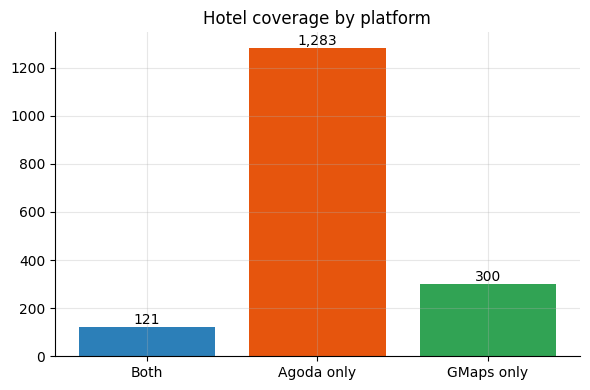

In [21]:
# How many hotels are covered by each platform / both?
cov = df.groupby("hotel_id")["source"].agg(lambda s: frozenset(s))
both = (cov == frozenset({"agoda", "googlemaps"})).sum()
ago = (cov == frozenset({"agoda"})).sum()
gmp = (cov == frozenset({"googlemaps"})).sum()
print(f"Hotels on BOTH platforms: {both:,}")
print(f"Agoda only:               {ago:,}")
print(f"Google Maps only:         {gmp:,}")
print(f"Total hotels:             {both + ago + gmp:,}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Both", "Agoda only", "GMaps only"], [both, ago, gmp], color=PALETTE[:3])
ax.set_title("Hotel coverage by platform")
for i, v in enumerate([both, ago, gmp]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 10. Key findings (data-driven summary)

In [22]:
r = pd.to_numeric(df["rating"], errors="coerce")
tmpc = df.dropna(subset=["rating", "distance2coastline"])
print("=" * 64)
print("KEY FINDINGS — Hotel Review Corpus EDA")
print("=" * 64)
print(f"1. Scale: {len(df):,} reviews across {df['hotel_id'].nunique():,} hotels; "
      f"{(df['language']=='en').sum():,} EN / {(df['language']=='vi').sum():,} VI.")
print(f"2. Sources are balanced: agoda {(df['source']=='agoda').sum():,} | "
      f"googlemaps {(df['source']=='googlemaps').sum():,}.")
print(f"3. Ratings are high & left-skewed: mean {r.mean():.2f}, median {r.median():.1f}; "
      f"{(r>=4).mean()*100:.0f}% are >=4 (positivity bias).")
print(f"4. Reviews are short but long-tailed: median {df['review_length'].median():.0f} tokens, "
      f"99th pct {df['review_length'].quantile(.99):.0f}, max {df['review_length'].max():,}.")
print(f"5. Corpus is recent: median stay year "
      f"{int(df['review_year'].median())}; ~{(df['review_year']>=2022).mean()*100:.0f}% from 2022+.")
print(f"6. Supply skews mid-market: median star class "
      f"{hotels['star_rating'].median():.0f}, median {hotels['numberrooms'].median():.0f} rooms.")
print(f"7. Coastal gradient: corr(rating, distance) = "
      f"{tmpc['rating'].corr(tmpc['distance2coastline']):.3f} (weak); "
      f"hotels span 0-{df['distance2coastline'].max():.0f} km, median "
      f"{hotels['distance2coastline'].median():.0f} km.")
print(f"8. Coverage is unbalanced: only {both:,} hotels appear on both platforms; "
      f"{ago:,} Agoda-only, {gmp:,} GMaps-only.")
print(f"9. Missingness is modest: rating {r.isna().mean()*100:.1f}% missing; "
      f"hotel attributes (yearopened) the least complete.")
print("=" * 64)

KEY FINDINGS — Hotel Review Corpus EDA
1. Scale: 252,848 reviews across 1,704 hotels; 135,326 EN / 117,522 VI.
2. Sources are balanced: agoda 125,347 | googlemaps 127,501.
3. Ratings are high & left-skewed: mean 4.21, median 4.8; 74% are >=4 (positivity bias).
4. Reviews are short but long-tailed: median 26 tokens, 99th pct 210, max 1,365.
5. Corpus is recent: median stay year 2023; ~60% from 2022+.
6. Supply skews mid-market: median star class 3, median 20 rooms.
7. Coastal gradient: corr(rating, distance) = 0.025 (weak); hotels span 0-401 km, median 41 km.
8. Coverage is unbalanced: only 121 hotels appear on both platforms; 1,283 Agoda-only, 300 GMaps-only.
9. Missingness is modest: rating 2.0% missing; hotel attributes (yearopened) the least complete.


### Detailed findings & interpretation

**Volume & composition.** The corpus comprises ~252.8k reviews over 1,704 hotels,
roughly balanced between English and Vietnamese and between Agoda and Google Maps.
This bilingual, two-platform design broadens establishment coverage and limits any
single platform's selection bias.

**Rating distribution.** Guest ratings are strongly left-skewed (mean ≈ 4.2,
median 5), consistent with the well-documented positivity bias of voluntary online
reviews. Analyses that treat the rating as a satisfaction signal should account for
this ceiling effect (e.g., ordinal models or class re-balancing).

**Review length.** The text is short-but-heavy-tailed: a median near 26 tokens with
a small fraction of very long narrative reviews. Length correlates only weakly with
rating, so verbosity is not a strong proxy for sentiment.

**Hotel supply.** The establishments are predominantly mid-market (median 3 stars,
~37 rooms) and overwhelmingly classified as "Hotel". Reviews per hotel are highly
unequal — a few high-profile properties dominate volume — which motivates
hotel-level weighting in aggregate comparisons.

**Temporal profile.** Activity is concentrated in recent years (post-2022), making
the corpus well suited to characterising the current post-pandemic market, with
visible intra-year seasonality.

**Coastal gradient.** Hotels span the full coastal-to-inland range (0 to ~400 km;
median ~44 km). The linear correlation between distance-to-coast and rating is weak,
suggesting that any coastal effect is non-linear or mediated by hotel class — a
question better addressed with the aspect-based and topic analyses downstream rather
than a simple correlation.

**Coverage caveat.** Only 121 hotels are observed on both platforms; the panel is
therefore unbalanced (largely Agoda-only), which must be controlled for in any
cross-platform comparison.
